In [ ]:
# Necessary for running on remote GPU
!pip install torch pandas transformers datasets peft scikit-learn tqdm accelerate huggingface_hub
!pip uninstall -y torchao
!pip install --upgrade --force-reinstall torch --index-url https://download.pytorch.org/whl/cu118

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA H100 80GB HBM3 MIG 4g.40gb


In [3]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import torch
from peft import PeftModel
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer


# Configure the base model, adapters, and data paths
BASE_MODEL_NAME = "meta-llama/Llama-3.1-8B"
STEP1_ADAPTER_PATH = "isco_step1_adapter"
STEP2_ADAPTER_PATH = "isco_step2_adapter_run_final42"  # Best model
ISCO_LEVEL3_PATH = "../data/isco_level3.csv"
LABELED_DATA_PATH = "../data/labeled.csv"
UNLABELED_DATA_PATH = "../data/unlabeled.parquet"
OUTPUT_DATA_PATH = "../data/labeled_corpus_final.parquet"
SEED = 42

In [4]:
import peft.tuners.tuners_utils

peft.tuners.tuners_utils._torch_supports_distributed = False


# Load the tokenizer
print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"


# Load valid ISCO codes for validating generated predictions
df_isco = pd.read_csv(ISCO_LEVEL3_PATH)

valid_codes = set(
    df_isco["isco_code"]
    .astype(str)
    .str.split(".")
    .str[0]
    .str.strip()
    .str.zfill(3)
)


# Load the base model
print("Loading base model...")

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map={"": 0},
)


# Merge the Step 1 continued pretraining adapter
print(f"Merging Step 1 adapter from: {STEP1_ADAPTER_PATH}...")

model = PeftModel.from_pretrained(
    model,
    STEP1_ADAPTER_PATH,
)

model = model.merge_and_unload()


# Load the Step 2 LoRA adapter
print(f"Loading Step 2 adapter from: {STEP2_ADAPTER_PATH}...")

model = PeftModel.from_pretrained(
    model,
    STEP2_ADAPTER_PATH,
)


# Set the model to evaluation mode
model.config.use_cache = True
model.eval()

print("Model loaded successfully and ready for inference!")

Loading tokenizer...
Loading base model...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Merging Step 1 adapter from: isco_step1_adapter...
Loading Step 2 adapter from: isco_step2_adapter_run_final42...
Model loaded successfully and ready for inference!


In [5]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split


# Load the labeled dataset
df_labeled = pd.read_csv(LABELED_DATA_PATH)


# Split the labeled dataset by class frequency
counts = df_labeled["isco"].value_counts()

single_classes = counts[counts == 1].index
two_classes = counts[counts == 2].index
common_classes = counts[counts >= 3].index

df_single = df_labeled[df_labeled["isco"].isin(single_classes)]
df_two = df_labeled[df_labeled["isco"].isin(two_classes)]
df_common = df_labeled[df_labeled["isco"].isin(common_classes)]


# Create the evaluation split
train_common, test_common = train_test_split(
    df_common,
    test_size=0.15,
    random_state=SEED,
    stratify=df_common["isco"],
)

train_common, eval_common = train_test_split(
    train_common,
    test_size=0.1765,
    random_state=SEED,
    stratify=train_common["isco"],
)

eval_df_check = eval_common


def build_instruction(row):
    return (
        "### Instruction:\n"
        "Classify the following job advertisement according to ISCO-08 "
        "(3-digit minor group code).\n\n"
        f"### Job Ad Title:\n{row['title']}\n\n"
        f"### Job Ad Text:\n{row['text_final']}\n\n"
        "### ISCO Code:\n"
    )


def extract_and_validate_code(generated_text, valid_codes):
    match = re.search(r"\b\d{3}\b", generated_text)

    if not match:
        return "INVALID", False

    candidate = match.group()

    return (
        (candidate, True)
        if candidate in valid_codes
        else ("INVALID", False)
    )


# Generate predictions for the evaluation split
preds = []
trues = []

for _, row in tqdm(
    eval_df_check.iterrows(),
    total=len(eval_df_check),
    desc="Evaluation",
):
    prompt = build_instruction(row)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=6,
            do_sample=False,
            repetition_penalty=1.2,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_ids = output[0][inputs["input_ids"].shape[1]:]

    generated_text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True,
    ).strip()

    pred_code, _ = extract_and_validate_code(
        generated_text,
        valid_codes,
    )

    true_code = (
        str(row["isco"])
        .split(".")[0]
        .strip()
        .zfill(3)
    )

    preds.append(pred_code)
    trues.append(true_code)


# Calculate evaluation metrics
check_acc = accuracy_score(
    trues,
    preds,
)

check_f1 = f1_score(
    trues,
    preds,
    average="macro",
    zero_division=0,
)


# Display evaluation results
print(f"Accuracy: {check_acc:.4f}")
print(f"Macro F1: {check_f1:.4f}")

Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]/opt/conda/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:601: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:606: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)
Evaluation: 100%|██████████| 104/104 [00:13<00:00,  7.52it/s]

Accuracy: 0.7404
Macro F1: 0.6728


In [6]:
# Load the unlabeled dataset
print("Loading unlabeled data...")

df_unlabeled = pd.read_parquet(
    UNLABELED_DATA_PATH,
)

print(
    f"Number of job advertisements to classify: "
    f"{len(df_unlabeled)}"
)

Loading unlabeled data...
Number of job advertisements to classify: 29847


In [7]:
import os


# Load existing predictions if available
if os.path.exists(OUTPUT_DATA_PATH):
    print(f"Loading existing labeled corpus from {OUTPUT_DATA_PATH}...")
    
    df_unlabeled = pd.read_parquet(
        OUTPUT_DATA_PATH,
    )

else:
    # Generate ISCO predictions for the unlabeled dataset
    predictions = []
    is_valid_flags = []

    for _, row in tqdm(
        df_unlabeled.iterrows(),
        total=len(df_unlabeled),
        desc="Labeling corpus",
    ):
        prompt = build_instruction(row)

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
        ).to(model.device)

        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=6,
                do_sample=False,
                repetition_penalty=1.2,
                pad_token_id=tokenizer.eos_token_id,
            )

        generated_ids = output[0][inputs["input_ids"].shape[1]:]

        generated_text = tokenizer.decode(
            generated_ids,
            skip_special_tokens=True,
        ).strip()

        pred_code, is_valid = extract_and_validate_code(
            generated_text,
            valid_codes,
        )

        predictions.append(pred_code)
        is_valid_flags.append(is_valid)


    # Add the predictions to the dataset
    df_unlabeled["isco"] = predictions
    df_unlabeled["isco_valid"] = is_valid_flags


    # Save the labeled dataset
    df_unlabeled.to_parquet(
        OUTPUT_DATA_PATH,
        index=False,
    )

    print(f"Saved labeled corpus to {OUTPUT_DATA_PATH}")

Loading existing labeled corpus from ../data/labeled_corpus_final.parquet...


--- Top 10 Predicted ISCO Codes ---
isco
251    2904
121    1649
222    1483
214    1458
241    1360
332    1358
243    1297
522    1224
132    1064
242    1051
Name: count, dtype: int64


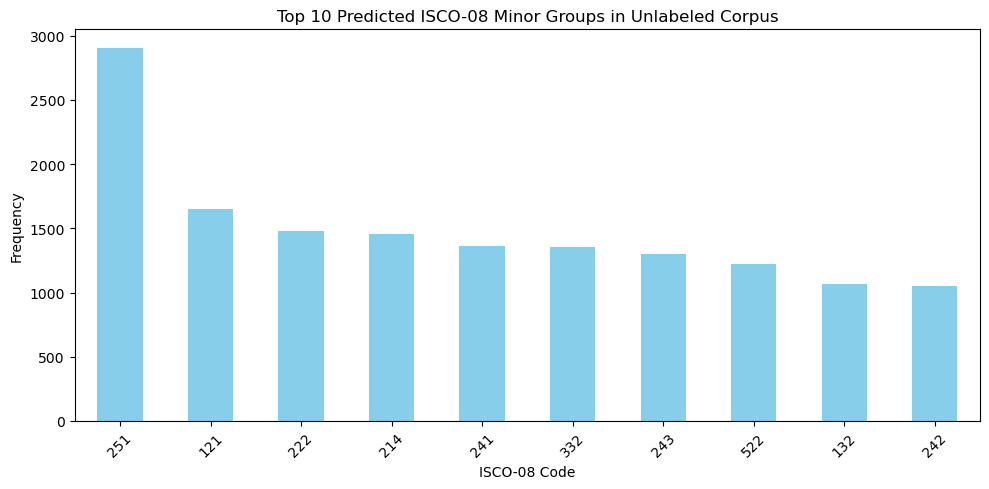


Number of invalid predictions: 2 out of 29847 (0.0%)

--- Spot-Checking: 10 Random Examples ---
Title: Brand Ambassador Lead
Predicted ISCO Code: 333 (valid: True)
--------------------------------------------------
Title: Physical Therapist
Predicted ISCO Code: 226 (valid: True)
--------------------------------------------------
Title: Patient Care Tech PRN
Predicted ISCO Code: 532 (valid: True)
--------------------------------------------------
Title: Veterinarian at Torrance Companion Animal Hospital in Torrance, California
Predicted ISCO Code: 225 (valid: True)
--------------------------------------------------
Title: Sr Director Biostatistics
Predicted ISCO Code: 213 (valid: True)
--------------------------------------------------
Title: Public Safety Technical Functional Analyst
Predicted ISCO Code: 252 (valid: True)
--------------------------------------------------
Title: SAP FICO Solutions Architect
Predicted ISCO Code: 251 (valid: True)
---------------------------------------

In [8]:
# Sanity checks

# Count the most frequently predicted ISCO codes
print("--- Top 10 Predicted ISCO Codes ---")

top_codes = (
    df_unlabeled["isco"]
    .value_counts()
    .head(10)
)

print(top_codes)


# Generate a bar plot
plt.figure(figsize=(10, 5))

top_codes.plot(
    kind="bar",
    color="skyblue",
)

plt.title("Top 10 Predicted ISCO-08 Minor Groups in Unlabeled Corpus")
plt.xlabel("ISCO-08 Code")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Count invalid predictions
invalid_count = (~df_unlabeled["isco_valid"]).sum()

print(
    f"\nNumber of invalid predictions: "
    f"{invalid_count} out of {len(df_unlabeled)} "
    f"({invalid_count / len(df_unlabeled):.1%})"
)


# Spot-check 10 randomly selected predictions
print("\n--- Spot-Checking: 10 Random Examples ---")

spot_check_sample = df_unlabeled.sample(
    10,
    random_state=42,
)

for _, row in spot_check_sample.iterrows():
    print(f"Title: {row['title']}")
    print(
        f"Predicted ISCO Code: {row['isco']} "
        f"(valid: {row['isco_valid']})"
    )
    print("-" * 50)

### Reliability by occupation (major group)

In [9]:
from sklearn.metrics import classification_report


# Load the test set results
test_results_df = pd.read_csv(
    "final_test_results_run_final42.csv",
)


# Calculate classification metrics for each major group
report = classification_report(
    test_results_df["true_major"].astype(str),
    test_results_df["pred_major"].astype(str),
    output_dict=True,
    zero_division=0,
)

reliability_by_major = (
    pd.DataFrame(report)
    .T
    .drop(
        index=["accuracy", "macro avg", "weighted avg"],
        errors="ignore",
    )
    .sort_values("f1-score")
)

reliability_by_major.index.name = "major_group"


# Display the major groups with the lowest reliability
print("Major groups with the lowest test-set reliability:")

print(
    reliability_by_major.head(5)[
        ["precision", "recall", "f1-score", "support"]
    ]
)


# Display the major groups with the highest reliability
print("\nMajor groups with the highest test-set reliability:")

print(
    reliability_by_major.tail(5)[
        ["precision", "recall", "f1-score", "support"]
    ]
)


# Calculate the share of full-corpus predictions in the least reliable groups
low_reliability_groups = reliability_by_major.head(3).index.tolist()

share_low_reliability = (
    df_unlabeled["isco"]
    .str[0]
    .isin(low_reliability_groups)
    .mean()
)

print(
    f"\nShare of the full corpus in the three least-reliable major groups: "
    f"{share_low_reliability:.1%}"
)

Major groups with the lowest test-set reliability:
             precision    recall  f1-score  support
major_group                                        
9             0.000000  0.000000  0.000000      4.0
5             0.555556  0.625000  0.588235      8.0
7             0.800000  0.800000  0.800000      5.0
3             0.818182  0.818182  0.818182     22.0
1             0.800000  0.888889  0.842105     18.0

Major groups with the highest test-set reliability:
             precision    recall  f1-score  support
major_group                                        
3             0.818182  0.818182  0.818182     22.0
1             0.800000  0.888889  0.842105     18.0
4             0.800000  1.000000  0.888889      8.0
2             0.941176  0.923077  0.932039     52.0
8             1.000000  1.000000  1.000000      2.0

Share of the full corpus in the three least-reliable major groups: 12.8%


### Comparison to external occupational statistics

We compare the predicted ISCO-08 major-group distribution against the US labor market
using the official BLS ISCO-08 <-> 2010 SOC crosswalk (https://www.bls.gov/soc/ISCO_SOC_Crosswalk.xls)
applied to the May 2023 OEWS national employment data (https://www.bls.gov/oes/special-requests/oesm23nat.zip).
Where one SOC code maps to multiple ISCO-08 codes, employment is split equally across
the linked ISCO codes (per BLS crosswalk documentation).

                  predicted_share  us_bls_share_2023    diff
isco_major_group                                            
0                             NaN             0.0003     NaN
1                          0.1567             0.0735  0.0833
2                          0.4409             0.1913  0.2497
3                          0.1943             0.1683  0.0260
4                          0.0578             0.1167 -0.0590
5                          0.0732             0.1810 -0.1078
6                          0.0033             0.0025  0.0007
7                          0.0387             0.0893 -0.0507
8                          0.0191             0.0606 -0.0415
9                          0.0162             0.1166 -0.1004


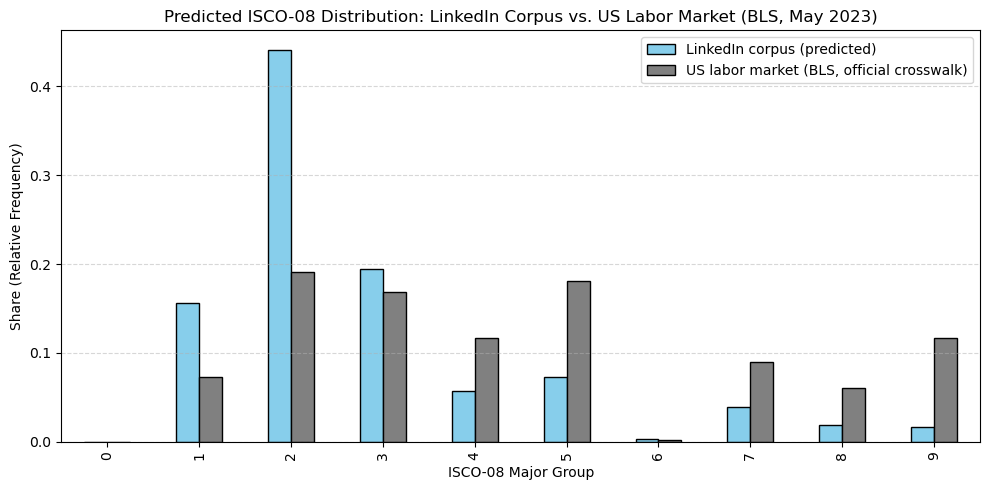

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Configure the input files
BLS_EXCEL_FILE = "../data/national_M2023_dl.xlsx"
CROSSWALK_FILE = "../data/isco_soc_crosswalk.xls"


# Load the BLS employment data
df_bls = pd.read_excel(
    BLS_EXCEL_FILE,
)

df_bls.columns = df_bls.columns.str.upper()

df_bls = df_bls[
    df_bls["O_GROUP"].str.lower() == "detailed"
].copy()

df_bls["TOT_EMP"] = pd.to_numeric(
    df_bls["TOT_EMP"],
    errors="coerce",
)

df_bls = df_bls.dropna(
    subset=["TOT_EMP"],
)

df_bls["soc_code"] = (
    df_bls["OCC_CODE"]
    .astype(str)
    .str.strip()
)


# Load and process the SOC-to-ISCO crosswalk
df_cross = pd.read_excel(
    CROSSWALK_FILE,
    header=6,
)

df_cross.columns = df_cross.columns.str.strip()

df_cross["soc_code"] = (
    df_cross["2010 SOC Code"]
    .astype(str)
    .str.strip()
)

df_cross["isco_code"] = (
    df_cross["ISCO-08 Code"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(4)
    .str.strip()
)

df_cross = df_cross.dropna(
    subset=["soc_code", "isco_code"],
)


# Resolve many-to-many SOC-to-ISCO mappings
soc_counts = (
    df_cross.groupby("soc_code")["isco_code"]
    .nunique()
    .reset_index()
)

soc_counts.columns = [
    "soc_code",
    "isco_count",
]

df_cross = pd.merge(
    df_cross,
    soc_counts,
    on="soc_code",
    how="left",
)

df_merged = pd.merge(
    df_bls,
    df_cross,
    on="soc_code",
    how="inner",
)

df_merged["weighted_emp"] = (
    df_merged["TOT_EMP"] / df_merged["isco_count"]
)


# Extract the ISCO-08 Major Group
df_merged["isco_major"] = (
    df_merged["isco_code"]
    .str[0]
)

df_merged = df_merged[
    df_merged["isco_major"].str.isdigit()
].copy()


# Calculate the BLS employment distribution
df_bls_grouped = (
    df_merged.groupby("isco_major")["weighted_emp"]
    .sum()
    .reset_index()
)

total_us_emp = df_bls_grouped["weighted_emp"].sum()

df_bls_grouped["us_bls_share_2023"] = (
    df_bls_grouped["weighted_emp"] / total_us_emp
)

df_bls_final = (
    df_bls_grouped
    .set_index("isco_major")["us_bls_share_2023"]
)


# Calculate the predicted ISCO distribution
predicted_major_shares = (
    df_unlabeled.loc[
        df_unlabeled["isco"] != "INVALID",
        "isco",
    ]
    .str[0]
    .value_counts(normalize=True)
    .sort_index()
)


# Combine the two distributions
comparison = pd.DataFrame({
    "predicted_share": predicted_major_shares,
    "us_bls_share_2023": df_bls_final,
})

comparison["diff"] = (
    comparison["predicted_share"]
    - comparison["us_bls_share_2023"]
)

comparison.index.name = "isco_major_group"

print(comparison.round(4))


# Generate a grouped bar chart
comparison[
    ["predicted_share", "us_bls_share_2023"]
].plot(
    kind="bar",
    figsize=(10, 5),
    color=["skyblue", "gray"],
    edgecolor="black",
)

plt.title(
    "Predicted ISCO-08 Distribution: "
    "LinkedIn Corpus vs. US Labor Market (BLS, May 2023)"
)

plt.xlabel("ISCO-08 Major Group")
plt.ylabel("Share (Relative Frequency)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5,
)

plt.legend([
    "LinkedIn corpus (predicted)",
    "US labor market (BLS, official crosswalk)",
])

plt.tight_layout()
plt.show()